In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from parameters import ParameterSet
import time
#from pyNN import nest

In [2]:
import nest as ns
ns.Install("stepcurrentmodule")
from pyNN import nest


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.4
 Built: Jan  9 2024 16:56:36

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.


Aug 15 15:21:39 Install [Info]: 
    loaded module Step Current Module

Aug 15 15:21:39 Install [Info]: 
    loaded module PyNN extensions for NEST


aeif_cond_exp_sc_nc(<parameters>)
1 3
91.0
EIF_cond_exp_isfa_ista(<parameters>)
1 3
93.0


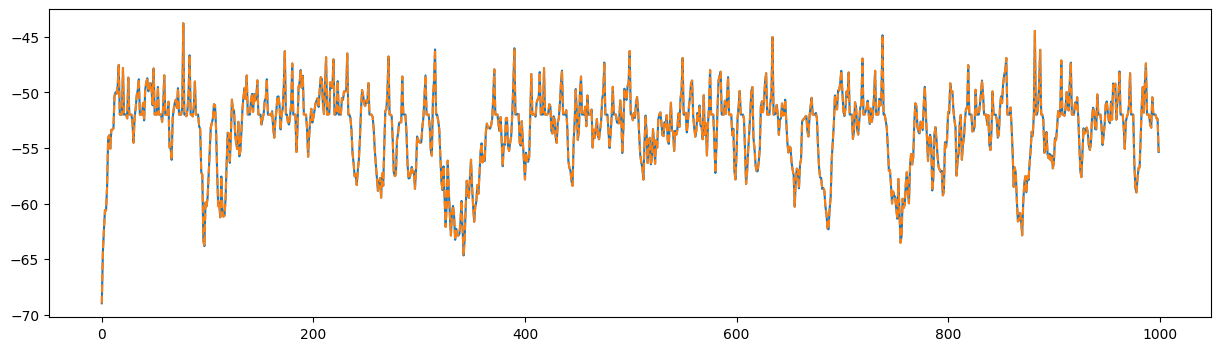

In [67]:
native_nest = True
def ntype(native_nest=True):
    if not native_nest:
        lgn_neuron_params = {
            'cm'         : 0.4548672566371681,   # nF, tot membrane capacitance (calculated from input resistance)
            'tau_refrac' : 2.7,   # ms, refractory period (ReinagelReid2000)
            'delta_T'    : 1,     # mV (Lo 1990 fit)
            'v_spike'    : 30.0,  # mV
            'v_thresh'   : -51,   # mV (Lo 1990 fit)
            'tau_m'      : 10.28, # ms (Bloomfield 1987)
            'v_rest'     : -60.0, # mV (Bloomfield 1987)
            'v_reset'    : -52,   # mV (Lo 1990 fit)
            'a'          : 40,    # nS (Lo 1990 fit)
            'b'          : 0.05,  # nA Lo 1990 fit
            'tau_w'      : 150,   # ms Lo 1990 fit
            'tau_syn_E'  : 5.,    # ms (not used)
            'tau_syn_I'  : 10.0,  # ms (not used)
        }
        return nest.EIF_cond_exp_isfa_ista(**lgn_neuron_params)
    else:
        lgn_neuron_params = {
            'C_m'         : 454.8672566371681,   # pF, tot membrane capacitance (calculated from input resistance)
            't_ref' : 2.7,   # ms, refractory period (ReinagelReid2000)
            'Delta_T'    : 1,     # mV (Lo 1990 fit)
            'V_peak'    : 30.0,  # mV
            'V_th'   : -51,   # mV (Lo 1990 fit)
            'g_L' : 454.8672566371681 / 10.28, # C_m / 10.28 ms membrane time constant (Bloomfield 1987)
            'E_L'     : -60.0, # mV (Bloomfield 1987)
            'V_reset'    : -52,   # mV (Lo 1990 fit)
            'a'          : 40,    # nS (Lo 1990 fit)
            'b'          : 50,  # pA Lo 1990 fit
            'tau_w'      : 150,   # ms Lo 1990 fit
            'tau_syn_ex'  : 5.,    # ms (not used)
            'tau_syn_in'  : 10.0,  # ms (not used)
        }
        return nest.native_cell_type("aeif_cond_exp_sc_nc")(**lgn_neuron_params)

def cell_response(amplitudes, dt, rec_type):
    #nest.setup(rngseed=0)
    print(lgn_neuron_type)
    cells = nest.Population(1, lgn_neuron_type)
    cells.record([rec_type], sampling_interval=1)

    times = np.linspace(0, len(amplitudes) * dt, len(amplitudes), endpoint=False)
    maxT = times[-1] + times[1]
    m,s = 1, 3
    mean, stdev = (m,s) #if native_nest else (m/1000, s/1000)
    print(mean,stdev)
    ncs = nest.NoisyCurrentSource(mean=mean,stdev=stdev,dt=dt)
    cells.inject(ncs)
    #cells.inject(nest.StepCurrentSource(times=times, amplitudes=amplitudes))

    nest.run(maxT)

    if rec_type == "V_m" or rec_type == 'v':
        assert "mV" in str(cells.get_data().segments[0].analogsignals[0].units)
        d = cells.get_data().segments[0].analogsignals[0]
        return np.array(d[-len(times) :].squeeze())
    elif rec_type == "spikes":
        return len(cells.get_data().segments[0].spiketrains[0]) / (maxT / 1000) # sp/s
    else:
        raise NotImplementedError


dt = 1
c = 1
plt.figure(figsize=(15,4))
native_nest = True
lgn_neuron_type = ntype(native_nest)
#r = cell_response(np.ones(1000//dt)*c,dt,rec_type='V_m' if native_nest else 'v')
print(cell_response(np.ones(1000//dt)*c,dt,rec_type='spikes'))
plt.plot(r)
#print(r.mean())
native_nest = False
lgn_neuron_type = ntype(native_nest)
#r = cell_response(np.ones(1000//dt)*c,dt,rec_type='V_m' if native_nest else 'v')
print(cell_response(np.ones(1000//dt)*c,dt,rec_type='spikes'))
#print(r.mean())
plt.plot(r,'--')
plt.show()